# 05 — Modèle Arbre de Décision
## Projet EDF — Prédiction de la Consommation Électrique

**Algorithme :** `DecisionTreeRegressor` (scikit-learn)

L'arbre de décision partitionne récursivement l'espace des features en régions homogènes. C'est le modèle le plus **interprétable** : on peut visualiser et expliquer chaque prédiction à un opérateur EDF.

**Critère de division :** `squared_error` (minimise la variance dans chaque feuille)

**Avantage principal ici :** Expliquer aux décideurs EDF **pourquoi** une prédiction est faite (règles métier lisibles)

In [2]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import time
from pathlib import Path

from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import TimeSeriesSplit

from models.evaluate import evaluate_model, r2_score, mape

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110})

PROCESSED_PATH = Path('../data/processed')
MODELS_PATH    = Path('../data/models_saved')
print(' Imports OK')

 Imports OK


In [3]:
X_train = np.load(PROCESSED_PATH / 'X_train.npy')
X_test  = np.load(PROCESSED_PATH / 'X_test.npy')
y_train = np.load(PROCESSED_PATH / 'y_train.npy')
y_test  = np.load(PROCESSED_PATH / 'y_test.npy')
feature_cols = pd.read_csv(PROCESSED_PATH / 'feature_cols.csv', header=None)[0].tolist()
print(f'Données chargées — Train: {X_train.shape}, Test: {X_test.shape}')

Données chargées — Train: (1748, 14), Test: (437, 14)


## 2. Analyse de la profondeur optimale (courbe de validation)

Profondeur optimale (MAPE test minimum) : max_depth = 12
MAPE train à depth=12 : 0.30%
MAPE test  à depth=12 : 2.06%


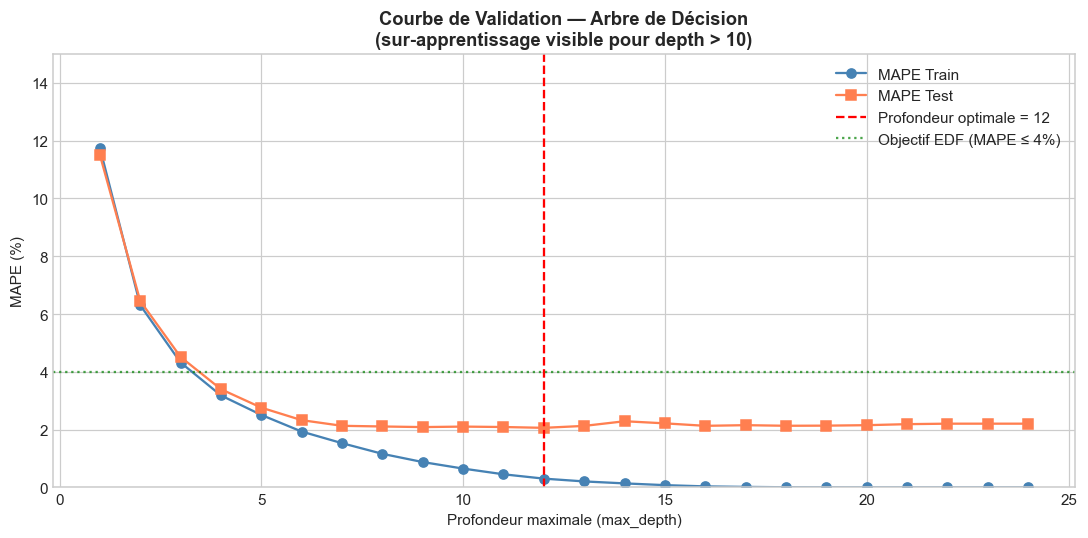

In [4]:
# Courbe d'apprentissage en fonction de la profondeur max
depths = range(1, 25)
mape_train_list, mape_test_list = [], []

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    mape_train_list.append(mape(y_train, dt.predict(X_train)))
    mape_test_list.append(mape(y_test, dt.predict(X_test)))

optimal_depth = depths[np.argmin(mape_test_list)]
print(f'Profondeur optimale (MAPE test minimum) : max_depth = {optimal_depth}')
print(f'MAPE train à depth={optimal_depth} : {mape_train_list[optimal_depth-1]:.2f}%')
print(f'MAPE test  à depth={optimal_depth} : {mape_test_list[optimal_depth-1]:.2f}%')

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, mape_train_list, 'o-', color='steelblue', label='MAPE Train')
ax.plot(depths, mape_test_list, 's-', color='coral', label='MAPE Test')
ax.axvline(optimal_depth, color='red', linestyle='--',
            label=f'Profondeur optimale = {optimal_depth}')
ax.axhline(4.0, color='green', linestyle=':', alpha=0.7, label='Objectif EDF (MAPE ≤ 4%)')
ax.set_xlabel('Profondeur maximale (max_depth)')
ax.set_ylabel('MAPE (%)')
ax.set_title('Courbe de Validation — Arbre de Décision\n(sur-apprentissage visible pour depth > 10)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 15)
plt.tight_layout()
plt.savefig(PROCESSED_PATH / '12_dt_validation_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Entraînement du modèle final

In [5]:
t0 = time.time()

dt_final = DecisionTreeRegressor(
    max_depth=optimal_depth,
    min_samples_split=20,
    min_samples_leaf=10,
    criterion='squared_error',
    random_state=42
)
dt_final.fit(X_train, y_train)

training_time = time.time() - t0
print(f'Entraînement terminé en {training_time:.2f}s')
print(f'Profondeur réelle de l\'arbre : {dt_final.get_depth()}')
print(f'Nombre de feuilles : {dt_final.get_n_leaves()}')
print(f'Nombre de noeuds   : {dt_final.tree_.node_count}')

Entraînement terminé en 0.01s
Profondeur réelle de l'arbre : 12
Nombre de feuilles : 129
Nombre de noeuds   : 257


## 4. Visualisation de l'arbre (sous-arbre pour lisibilité)

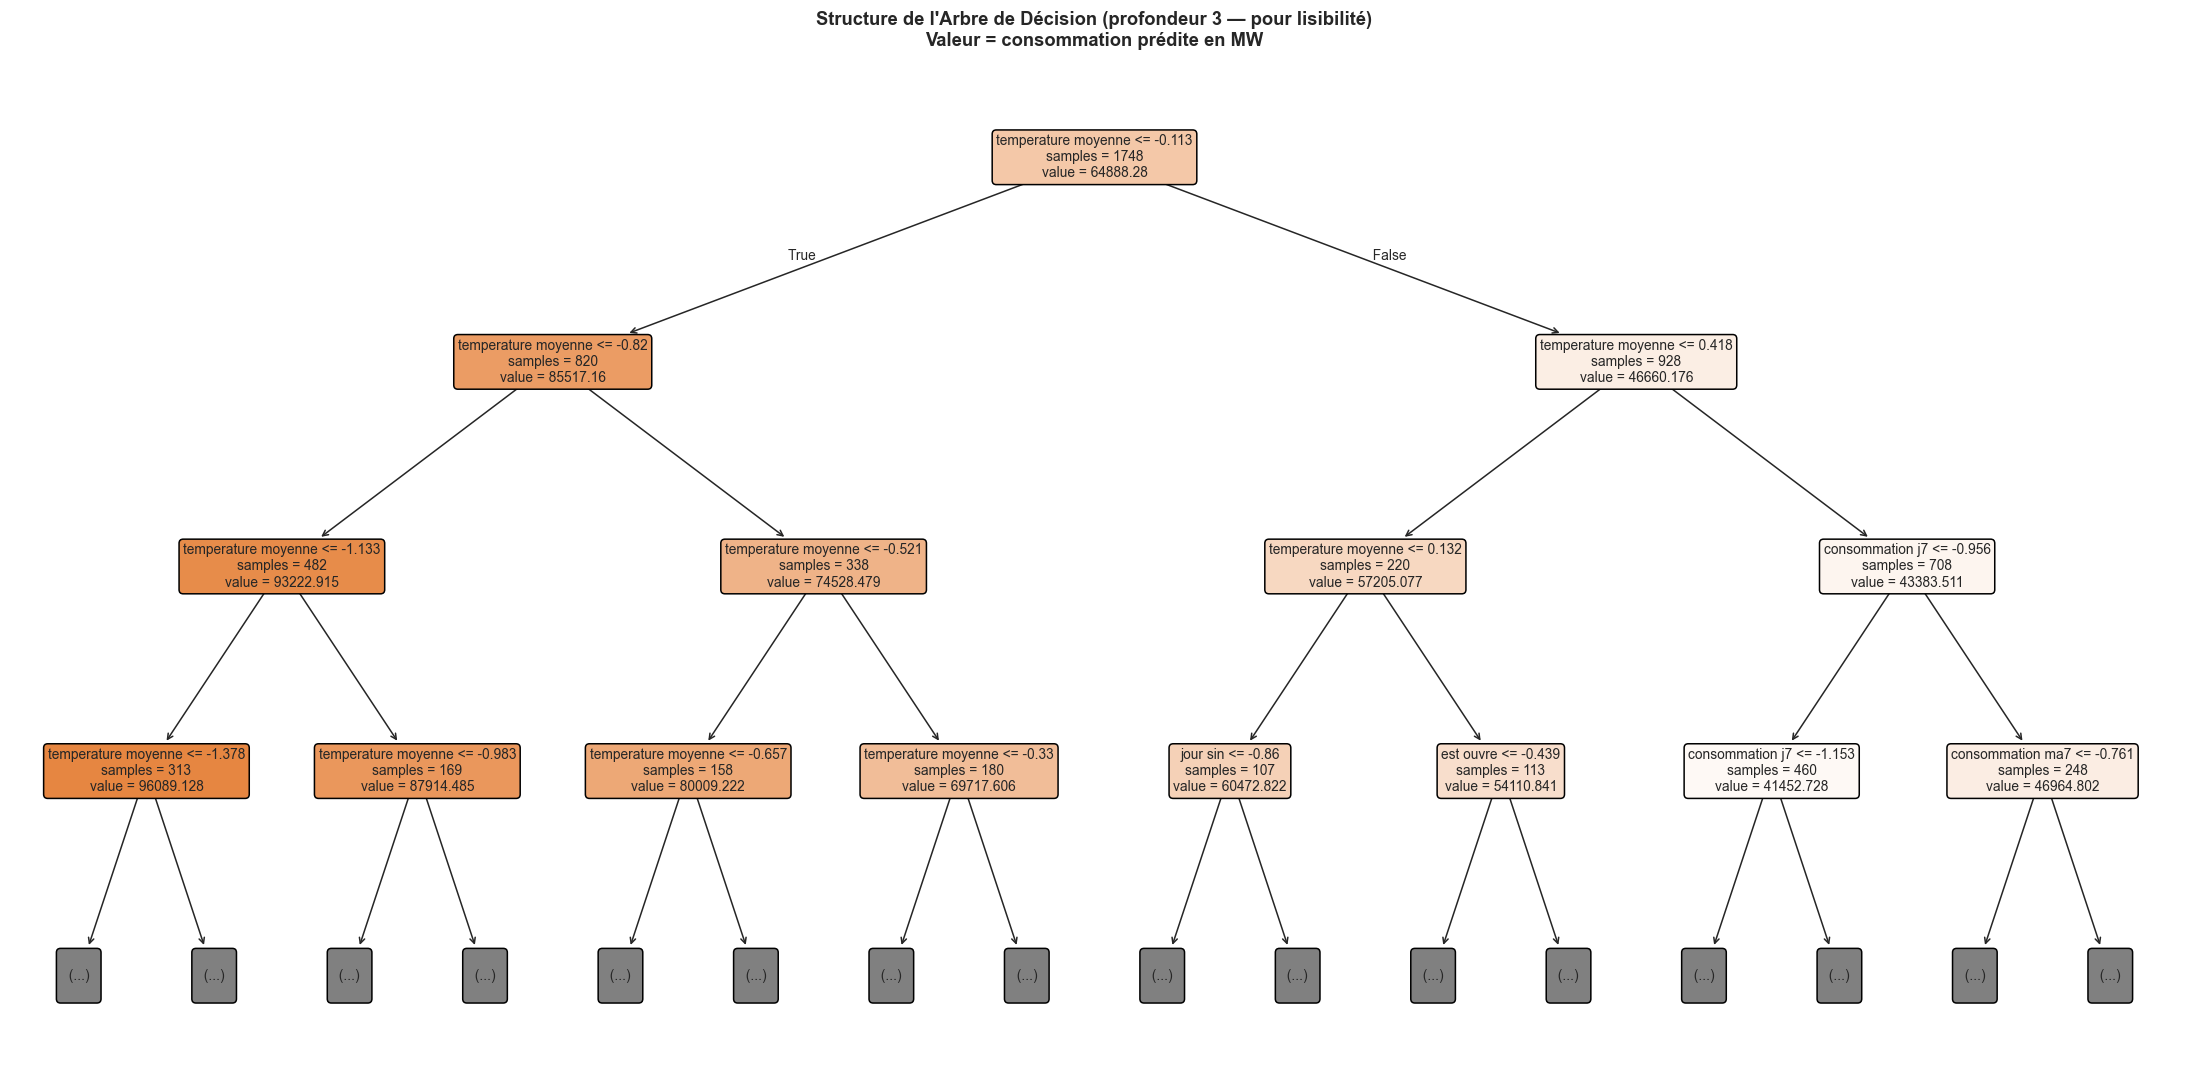


=== Règles de l'arbre (3 premiers niveaux) ===
|--- temperature_moyenne <= -0.11
|   |--- temperature_moyenne <= -0.82
|   |   |--- temperature_moyenne <= -1.13
|   |   |   |--- temperature_moyenne <= -1.38
|   |   |   |   |--- value: [98474.68]
|   |   |   |--- temperature_moyenne >  -1.38
|   |   |   |   |--- value: [94108.14]
|   |   |--- temperature_moyenne >  -1.13
|   |   |   |--- temperature_moyenne <= -0.98
|   |   |   |   |--- value: [90030.11]
|   |   |   |--- temperature_moyenne >  -0.98
|   |   |   |   |--- value: [85669.85]
|   |--- temperature_moyenne >  -0.82
|   |   |--- temperature_moyenne <= -0.52
|   |   |   |--- temperature_moyenne <= -0.66
|   |   |   |   |--- value: [81711.28]
|   |   |   |--- temperature_moyenne >  -0.66
|   |   |   |   |--- value: [77442.62]
|   |   |--- temperature_moyenne >  -0.52
|   |   |   |--- temperature_moyenne <= -0.33
|   |   |   |   |--- value: [72543.08]
|   |   |   |--- temperature_moyenne >  -0.33
|   |   |   |   |--- value: [6783

In [6]:
# On visualise un arbre simplifié (max_depth=4) pour la lisibilité
dt_simple = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=42)
dt_simple.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_simple,
    feature_names=[f.replace('_', ' ') for f in feature_cols],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=False,
    max_depth=3  # Limiter l'affichage à 3 niveaux
)
ax.set_title('Structure de l\'Arbre de Décision (profondeur 3 — pour lisibilité)\n'
              'Valeur = consommation prédite en MW', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_PATH / '13_dt_arbre.png', dpi=100, bbox_inches='tight')
plt.show()

# Export textuel des 3 premières règles
print('\n=== Règles de l\'arbre (3 premiers niveaux) ===')
print(export_text(dt_simple, feature_names=feature_cols, max_depth=3))

## 5. Évaluation


───────────────────────────────────────────────────────
  ÉVALUATION — Arbre de Décision
───────────────────────────────────────────────────────
  R² Score          : 0.9920  (cible ≥ 0.90)
  RMSE              : 1,916 MW
  MAPE              : 2.07 %  (cible ≤ 4 %)
  MAE               : 1,288 MW
  Accuracy ±10 %    : 98.9 %
  Accuracy ±5 %     : 90.6 %
  Tps inférence     : 0.1 ms  (cible < 500 ms)
  Échantillons test : 437
───────────────────────────────────────────────────────

  Objectifs EDF :
    Ok  R² ≥ 0.90
    Ok  MAPE ≤ 4 %
    Ok  Accuracy ±10 % ≥ 90 %
    Ok  Inférence < 500 ms

R² train : 0.9962
R² test  : 0.9920


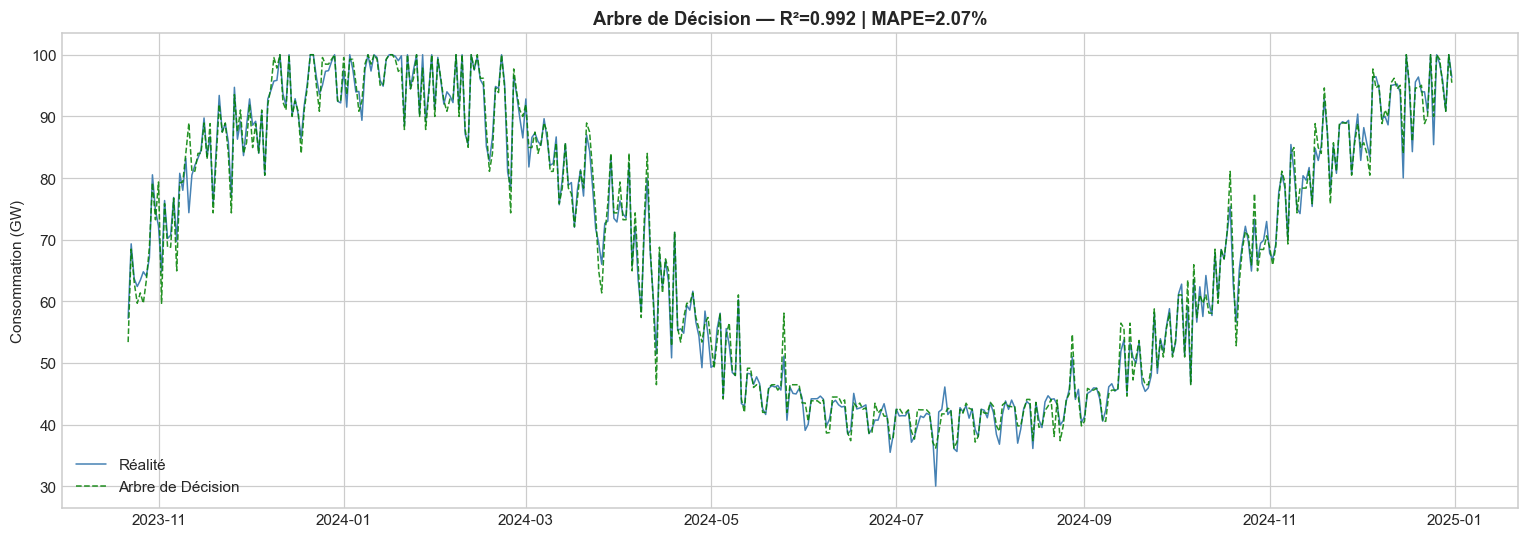

In [7]:
metrics_dt = evaluate_model(dt_final, X_test, y_test, model_name='Arbre de Décision')

# Comparaison train/test pour illustrer le sur-apprentissage résiduel
print(f'\nR² train : {r2_score(y_train, dt_final.predict(X_train)):.4f}')
print(f'R² test  : {r2_score(y_test, dt_final.predict(X_test)):.4f}')

y_pred_dt = dt_final.predict(X_test)

# Visualisation
df_proc = pd.read_parquet(PROCESSED_PATH / 'dataset_processed.parquet')
dates_test = df_proc['date'].values[len(y_train):len(y_train) + len(y_test)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_test, y_test / 1000, label='Réalité', linewidth=1, color='steelblue')
ax.plot(dates_test, y_pred_dt / 1000, label='Arbre de Décision', linewidth=1,
         color='green', linestyle='--', alpha=0.85)
ax.set_ylabel('Consommation (GW)')
ax.set_title(f'Arbre de Décision — R²={metrics_dt["r2"]:.3f} | MAPE={metrics_dt["mape_pct"]:.2f}%',
              fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_PATH / '14_dt_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Sauvegarde

In [8]:
model_path = MODELS_PATH / 'decision_tree_v1.pkl'
joblib.dump(dt_final, model_path)

metrics_dt['training_time_s'] = round(training_time, 3)
metrics_dt['hyperparameters'] = {'max_depth': optimal_depth, 'min_samples_split': 20, 'min_samples_leaf': 10}
pd.Series(metrics_dt).to_json(MODELS_PATH / 'metrics_decision_tree.json')

print(f' Modèle sauvegardé → {model_path}')
print(f'\n RÉSUMÉ Arbre de Décision :')
print(f'   R² = {metrics_dt["r2"]}  |  MAPE = {metrics_dt["mape_pct"]}%  |  Inférence = {metrics_dt["inference_ms"]} ms')
print('\n Remarque : MAPE > 4% — Arbre de Décision conservé pour l\'interprétabilité,')
print('   pas pour la performance brute (cf. Random Forest pour la production)')

 Modèle sauvegardé → ..\data\models_saved\decision_tree_v1.pkl

 RÉSUMÉ Arbre de Décision :
   R² = 0.992  |  MAPE = 2.07%  |  Inférence = 0.08 ms

 Remarque : MAPE > 4% — Arbre de Décision conservé pour l'interprétabilité,
   pas pour la performance brute (cf. Random Forest pour la production)
